## Setup & Connection

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from scipy import stats
from dotenv import load_dotenv

# 1. SETUP & DB CONNECTION
load_dotenv(dotenv_path='../.env')
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

## Load data & clean 

In [2]:
# 2. DATA LOADING (The "Master Join")
# We combine performance, team info, and enrichment data in one SQL query
query = """
SELECT 
    p.team_id, p.season_year, p.points, p.final_position, p.is_top_5,
    t.name, t.city, t.latitude, t.longitude,
    sh.stadium_capacity,
    e.transfer_spend_euro, e.transfer_income_euro, e.net_transfer_spend_euro
FROM team_season_performance p
JOIN teams t ON p.team_id = t.team_id
LEFT JOIN team_stadium_history sh ON p.team_id = sh.team_id AND p.season_year = sh.season_year
LEFT JOIN team_enrichment_data e ON p.team_id = e.team_id AND p.season_year = e.season_year
"""

df = pd.read_sql(query, engine)

if df.empty:
    print("❌ CRITICAL: No data found! Run Script C and D first.")
else:
    print(f"✅ Data loaded: {df.shape[0]} rows and {df.shape[1]} features ready for analysis.")

✅ Data loaded: 60 rows and 13 features ready for analysis.


## Feature engineering

In [7]:
# 3. FEATURE ENGINEERING: Points per 10M Euro Spend
# Creating an efficiency metric (Moneyball style)
df['spend_efficiency'] = df['points'] / (df['transfer_spend_euro'] / 10_000_000)

df.head()

,team_id,season_year,points,final_position,is_top_5,name,city,latitude,longitude,stadium_capacity,transfer_spend_euro,transfer_income_euro,net_transfer_spend_euro,spend_efficiency
0,33,2021,58,6,0,Manchester United,Manchester,53.4631,-2.2913,76212,142000000.0,31100000.0,-110900000.0,4.084507
1,33,2022,75,3,1,Manchester United,Manchester,53.4631,-2.2913,76212,243150000.0,23650000.0,-219500000.0,3.084516
2,33,2023,60,8,0,Manchester United,Manchester,53.4631,-2.2913,76212,210700000.0,63770000.0,-146930000.0,2.847651
3,34,2021,49,11,0,Newcastle,Newcastle upon Tyne,54.9756,-1.6217,52758,130500000.0,0.0,-130500000.0,3.754789
4,34,2022,71,4,1,Newcastle,Newcastle upon Tyne,54.9756,-1.6217,52758,189100000.0,14060000.0,-175040000.0,3.754627


## EDA: Correlation between spending and standing

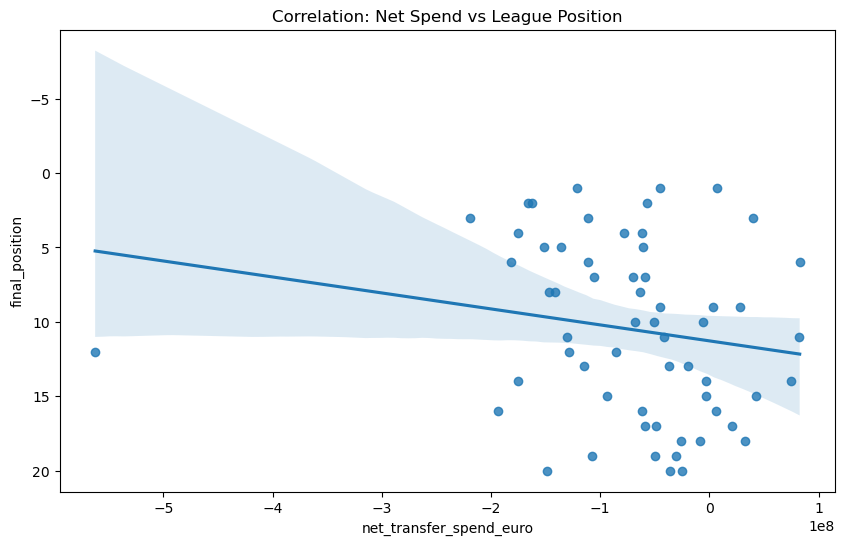

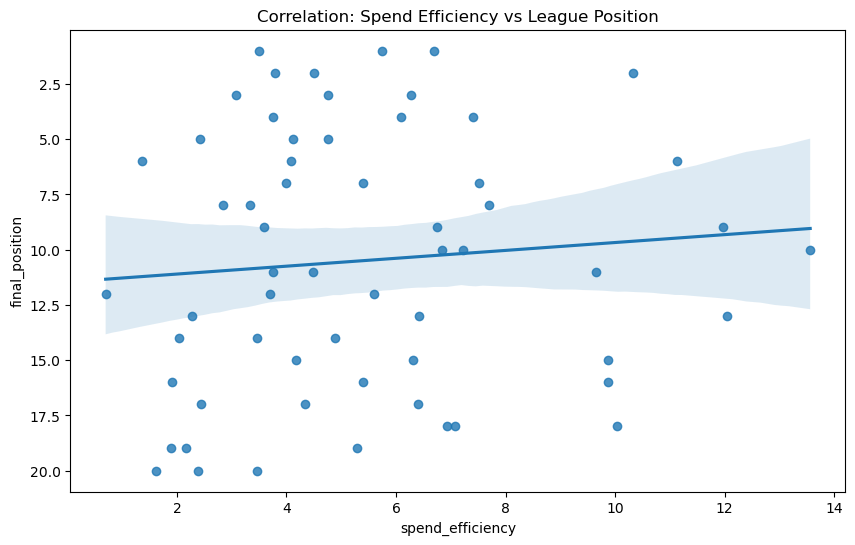

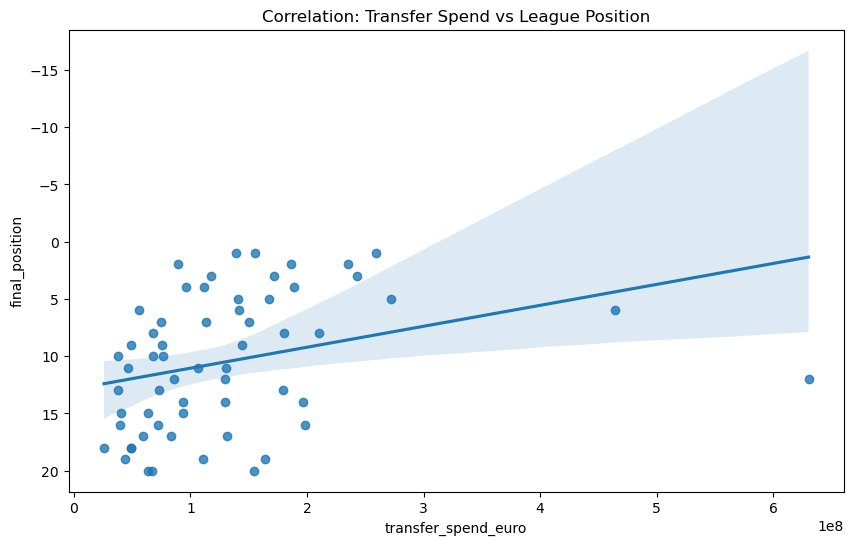

In [6]:
# 4. EDA: Visualizing Net Spend vs Position
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='net_transfer_spend_euro', y='final_position')
plt.gca().invert_yaxis() # Position 1 is better than 20
plt.title('Correlation: Net Spend vs League Position')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='spend_efficiency', y='final_position')
plt.gca().invert_yaxis() # Position 1 is better than 20
plt.title('Correlation: Spend Efficiency vs League Position')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='transfer_spend_euro', y='final_position')
plt.gca().invert_yaxis() # Position 1 is better than 20
plt.title('Correlation: Transfer Spend vs League Position')
plt.show()

## Visualization of what 

In [5]:
# 5. STATISTICAL TEST (Bonus Requirement #4)
correlation, p_value = stats.pearsonr(df['net_transfer_spend_euro'].fillna(0), df['points'])
print(f"Pearson Correlation (Spend vs Points): {correlation:.2f} (p-value: {p_value:.4f})")

Pearson Correlation (Spend vs Points): -0.15 (p-value: 0.2498)
